<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <img src="../assets/branding/logoUgrupo.png" alt="Universidad del Magdalena y GIDSYC" style="height: 76px; max-width: 34%; object-fit: contain;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Modelos de difusión para IA generativa</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 07</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Modelos de difusión condicionales</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Semillero GIDSYC | Facultad de Ingenierías | Programa de Ingeniería de Sistemas</div>
    </div>
    <img src="../assets/branding/logo_semillero.png" alt="Semillero GIDSYC" style="height: 74px; object-fit: contain;">
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
  <div><strong>Grupo:</strong> GIDSYC</div>
  <div><strong>Unidad:</strong> Semillero GIDSYC</div>
  <div><strong>Universidad:</strong> Universidad del Magdalena</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>

## Pregunta directriz

> ¿Cómo se modifica un DDPM para generar una imagen de la clase solicitada y no solamente una muestra plausible de la mezcla?

El notebook 06 mostró que un dataset multicategoría induce una mezcla de distribuciones. Si ignoramos la etiqueta, el modelo aprende la marginal $p_{\mathrm{data}}(x)$: una distribución que reúne casas, gatos, árboles, peces y manzanas. Esa formulación permite generación no condicional, pero no ofrece una interfaz explícita para solicitar una categoría.

Este notebook introduce la primera extensión condicional: la red de denoising recibe una etiqueta discreta $y$. El proceso directo de difusión no cambia. Lo que cambia es la función aprendida: pasamos de $\epsilon_\theta(x_t,t)$ a $\epsilon_\theta(x_t,t,y)$.

## Objetivos

Al finalizar este notebook, el estudiante debería estar en capacidad de:

1. Formular el objetivo DDPM condicional para una etiqueta discreta.
2. Explicar por qué el proceso directo $q(x_t\mid x_0)$ no necesita depender de la clase.
3. Implementar embeddings de clase como representación computacional de la condición.
4. Entrenar una U-Net mínima que predice ruido usando $x_t$, $t$ y $y$.
5. Comparar muestras generadas para distintas clases bajo el mismo procedimiento inverso.
6. Identificar las limitaciones de un condicionamiento supervisado simple antes de introducir guidance.

## Marco conceptual

En un modelo no condicional, la red recibe una imagen ruidosa $x_t$ y un tiempo $t$. Su tarea es estimar el ruido que permitió construir $x_t$ desde una imagen limpia. Cuando el dataset contiene varias clases, esa tarea se vuelve ambigua: a un mismo nivel de ruido pueden existir trayectorias compatibles con componentes semánticas distintas.

La condición $y$ reduce esa ambigüedad. No cambia el espacio de datos ni la definición de ruido, pero sí cambia la información disponible para la red. La etiqueta actúa como una coordenada semántica externa: le indica al modelo qué componente de la mezcla debe privilegiar durante el denoising.

Computacionalmente, una etiqueta discreta no se introduce como texto ni como una explicación lingüística. Se representa mediante un embedding aprendible. Si hay $K$ clases, el modelo aprende una tabla $E\in\mathbb{R}^{K\times m}$. Cada clase selecciona una fila de esa tabla, y esa representación se combina con el embedding temporal para modular los bloques convolucionales.

## Formulación matemática

Sea

$$
\mathcal{D}
=
\{(x_i,y_i)\}_{i=1}^{N},
\qquad
x_i\in\mathbb{R}^{d},
\qquad
y_i\in\{1,\dots,K\}.
$$

El proceso directo se mantiene igual que en los notebooks anteriores:

$$
q(x_t\mid x_0)
=
\mathcal{N}
\left(
x_t;
\sqrt{\bar{\alpha}_t}x_0,
(1-\bar{\alpha}_t)I
\right).
$$

También podemos simular cualquier tiempo de forma cerrada:

$$
x_t
=
\sqrt{\bar{\alpha}_t}x_0
+
\sqrt{1-\bar{\alpha}_t}\epsilon,
\qquad
\epsilon\sim\mathcal{N}(0,I).
$$

La diferencia aparece en la función que aprende la red. En lugar de aproximar una sola función de denoising,

$$
\epsilon_\theta(x_t,t),
$$

entrenamos una función condicionada:

$$
\epsilon_\theta(x_t,t,y).
$$

El objetivo de entrenamiento queda

$$
\mathcal{L}_{\mathrm{cond}}(\theta)
=
\mathbb{E}_{y\sim\widehat{\pi},\,x_0\sim\widehat{p}(x\mid y),\,t,\epsilon}
\left[
\left\|
\epsilon
-
\epsilon_\theta(x_t,t,y)
\right\|_2^2
\right].
$$

Para una etiqueta discreta usamos una tabla de embeddings:

$$
e_y = E[y],
\qquad
E\in\mathbb{R}^{K\times m}.
$$

En este notebook combinaremos la información temporal y semántica mediante una suma simple:

$$
h(t,y)
=
\phi_t(t)
+
\phi_y(e_y).
$$

Durante el muestreo, fijar una etiqueta produce una cadena inversa condicionada:

$$
x_T\sim\mathcal{N}(0,I),
\qquad
x_{t-1}\sim p_\theta(x_{t-1}\mid x_t,y).
$$

Por tanto, solicitar una clase no significa cambiar la distribución inicial de ruido. Significa cambiar la función de denoising aplicada en cada paso inverso.

<div style="margin: 18px 0 10px 0; text-align: center;">
  <img src="../assets/figures/formulacion_difusion_condicional.png" alt="Formulación de un DDPM condicional" style="max-width: 100%; border: 1px solid #d0d7de; border-radius: 6px;" />
</div>

<div style="text-align: center; color: #4a5568; font-size: 0.95em; margin-bottom: 6px;">
  El proceso directo conserva la misma distribución gaussiana; la condición entra en la red inversa mediante una representación aprendible de la clase.
</div>

## Preparación del entorno

El entrenamiento usa PyTorch y, si está disponible, GPU. El notebook queda preparado para reusar un checkpoint: la primera ejecución entrena el modelo y lo guarda; las ejecuciones siguientes cargan el modelo entrenado.

In [1]:
import math
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

CWD = Path.cwd()
if CWD.name == "notebooks":
    ROOT = CWD.parent
elif (CWD / "src" / "difusion").exists():
    ROOT = CWD
else:
    ROOT = CWD / "courses" / "modelos_difusion_ia_generativa"
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from difusion.data.quickdraw import load_quickdraw_npz

DATASET_PATH = ROOT / "data" / "quickdraw" / "processed" / "quickdraw_5class_10k_each_28x28.npz"
CHECKPOINT_DIR = ROOT / "models"
CHECKPOINT_PATH = CHECKPOINT_DIR / "quickdraw_5class_conditional_tiny_unet.pt"

SEED = 20260424
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["image.cmap"] = "gray_r"

print("PyTorch:", torch.__version__)
print("Dispositivo:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(DEVICE))
else:
    print("Advertencia: no se detectó GPU. El entrenamiento completo tardará bastante más.")
print("Checkpoint:", CHECKPOINT_PATH.relative_to(ROOT))

PyTorch: 2.8.0+cu126
Dispositivo: cuda:0
GPU: NVIDIA RTX A6000
Checkpoint: models/quickdraw_5class_conditional_tiny_unet.pt


## Criterio experimental

El experimento debe probar una idea concreta: la misma red de difusión puede generar muestras de distintas componentes si recibe la etiqueta adecuada. Para que esa lectura sea limpia, mantendremos una arquitectura pequeña, una agenda de ruido estándar y un dataset balanceado.

El experimento no pretende competir con modelos generativos modernos ni optimizar calidad perceptual. El criterio de éxito es más específico: al fijar $y$, las muestras finales deben mostrar estructura visual compatible con esa clase. Además, al usar la misma semilla inicial con diferentes etiquetas, debería observarse que el condicionamiento cambia la trayectoria de denoising.

## Dataset y mini-lotes condicionados

Cargamos el subconjunto multicategoría de QuickDraw y seleccionamos una muestra balanceada para entrenamiento. Esta decisión evita que el prior empírico favorezca artificialmente una clase durante el aprendizaje.

In [2]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró {DATASET_PATH}. "
        "Genere el dataset multicategoría antes de ejecutar este notebook."
    )

split = load_quickdraw_npz(DATASET_PATH, split="train")
x_all = split.normalized_images
y_all = split.labels.astype(np.int64)
class_names = np.array(split.class_names)
NUM_CLASSES = len(class_names)

MAX_PER_CLASS = 6_000
BATCH_SIZE = 256

rng = np.random.default_rng(SEED)
selected = []
for k in range(NUM_CLASSES):
    idx = np.flatnonzero(y_all == k)
    selected.append(rng.choice(idx, size=min(MAX_PER_CLASS, len(idx)), replace=False))
selected = np.concatenate(selected)
rng.shuffle(selected)

x_train = x_all[selected]
y_train = y_all[selected]

x_tensor = torch.from_numpy(x_train[:, None, :, :]).float()
y_tensor = torch.from_numpy(y_train).long()
loader = DataLoader(
    TensorDataset(x_tensor, y_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=0,
)

counts = np.bincount(y_train, minlength=NUM_CLASSES)
print("Clases:", class_names.tolist())
print("Muestras usadas:", len(x_train))
for name, count in zip(class_names, counts):
    print(f"{name:>6s}: {count:5d}")

Clases: ['house', 'cat', 'tree', 'fish', 'apple']
Muestras usadas: 30000
 house:  6000
   cat:  6000
  tree:  6000
  fish:  6000
 apple:  6000


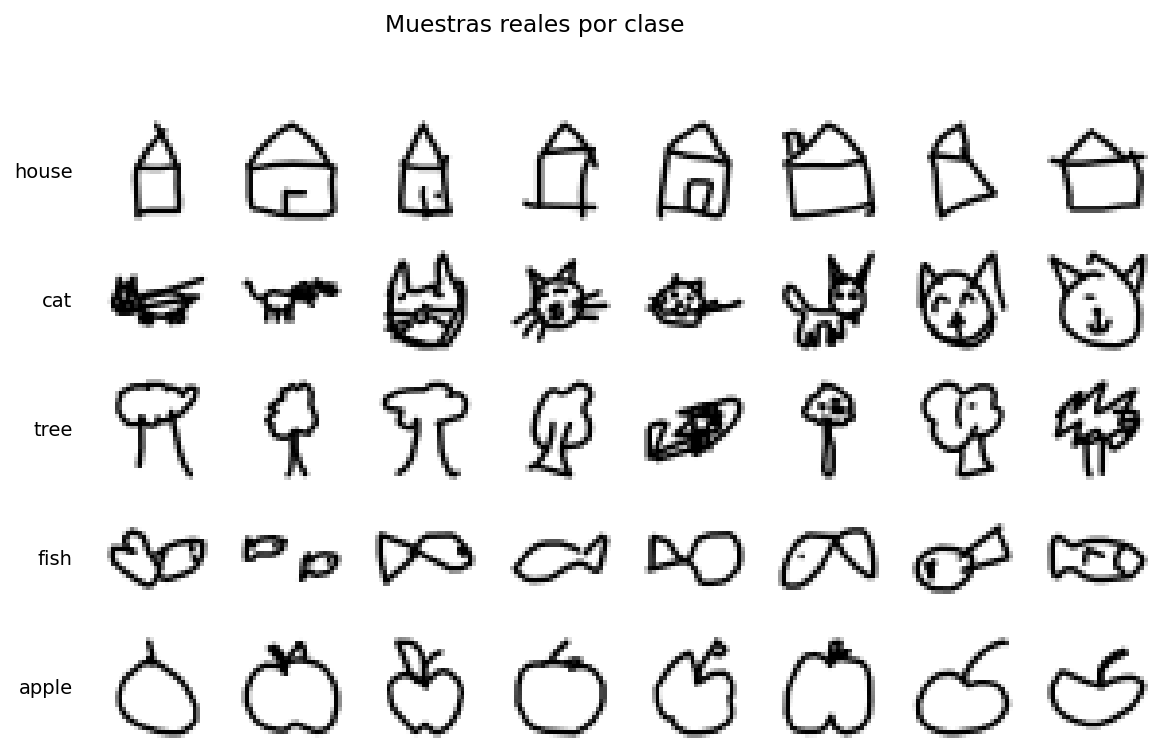

In [3]:
samples_per_class = 8
fig, axes = plt.subplots(NUM_CLASSES, samples_per_class, figsize=(samples_per_class * 1.15, NUM_CLASSES * 1.05))
for k, name in enumerate(class_names):
    idx = np.flatnonzero(y_train == k)
    chosen = rng.choice(idx, size=samples_per_class, replace=False)
    for j, image_idx in enumerate(chosen):
        ax = axes[k, j]
        ax.imshow((x_train[image_idx] + 1.0) / 2.0, vmin=0, vmax=1)
        ax.axis("off")
        if j == 0:
            ax.text(-0.28, 0.5, str(name), transform=ax.transAxes, ha="right", va="center", fontsize=10)
fig.suptitle("Muestras reales por clase", y=1.02)
fig.tight_layout(rect=[0.08, 0.0, 1.0, 0.97])

## Agenda de ruido

Usaremos una agenda lineal de varianza con $T=500$ pasos. El número de pasos reduce el costo de entrenamiento y muestreo sin abandonar la estructura DDPM: se entrena con tiempos discretos uniformemente muestreados y se genera recorriendo la cadena inversa desde $T$ hasta $1$.

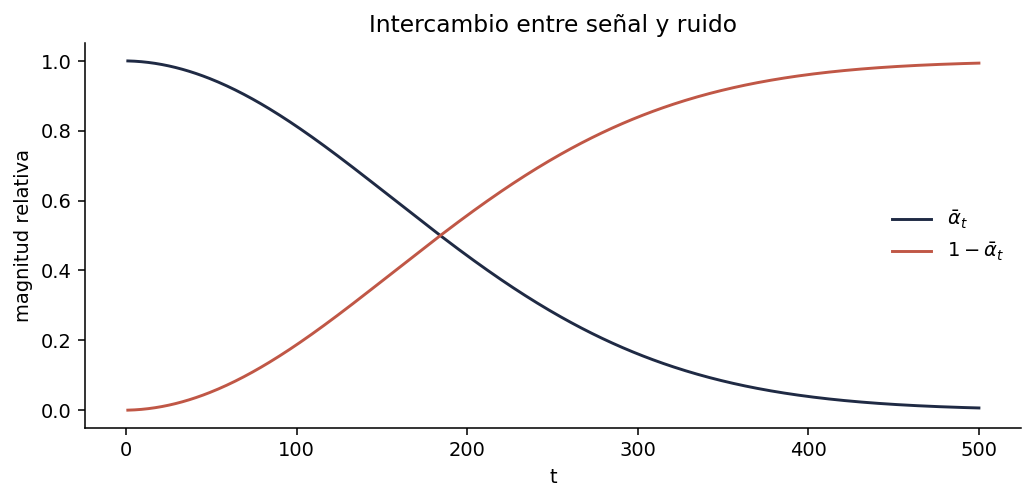

In [4]:
T = 500
beta_inicio = 1e-4
beta_fin = 2e-2

betas = torch.linspace(beta_inicio, beta_fin, T, dtype=torch.float32, device=DEVICE)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)


def q_sample(x0, t_index, eps=None):
    if eps is None:
        eps = torch.randn_like(x0)
    alpha_bar_t = alpha_bars[t_index].view(-1, 1, 1, 1)
    xt = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1.0 - alpha_bar_t) * eps
    return xt, eps


fig, ax = plt.subplots(figsize=(7.5, 3.7))
ax.plot(torch.arange(1, T + 1).cpu(), alpha_bars.cpu(), color="#1f2a44", label=r"$\bar{\alpha}_t$")
ax.plot(torch.arange(1, T + 1).cpu(), (1.0 - alpha_bars).cpu(), color="#c05746", label=r"$1-\bar{\alpha}_t$")
ax.set_xlabel("t")
ax.set_ylabel("magnitud relativa")
ax.set_title("Intercambio entre señal y ruido")
ax.legend(frameon=False)
fig.tight_layout()

## Codificación temporal y semántica

El modelo necesita representar dos variables discretas: el tiempo de difusión y la etiqueta de clase. Para el tiempo usamos una codificación sinusoidal, de modo que tiempos cercanos tengan representaciones relacionadas y el modelo pueda generalizar de forma suave entre niveles de ruido. Para la clase usamos una tabla aprendible de embeddings.

En términos computacionales, cada mini-lote produce dos vectores: uno asociado a $t$ y otro asociado a $y$. La suma de ambos define la condición interna $h(t,y)$ que será inyectada en los bloques convolucionales:

$$
h(t,y)=\phi_t(t)+\phi_y(E[y]).
$$

Esta forma no es la única posible, pero permite aislar el mecanismo central sin introducir una arquitectura innecesariamente compleja.

## Arquitectura condicional

La arquitectura conserva la idea de una U-Net pequeña: bloques convolucionales, dos reducciones espaciales, dos expansiones y conexiones laterales. La única modificación conceptual es que cada bloque recibe una representación condicional $h(t,y)$, construida al sumar el embedding temporal y el embedding de clase.

Esta elección mantiene controlado el experimento. No introduce atención, texto, transformers ni guidance. Antes de ampliar la arquitectura, conviene verificar que el condicionamiento discreto básico ya resuelve el problema semántico principal.

In [5]:
def sinusoidal_time_embedding(t_index, dim=96):
    half = dim // 2
    t = t_index.float() / max(T - 1, 1)
    freqs = torch.exp(
        -math.log(10000.0) * torch.arange(half, device=t_index.device) / max(half - 1, 1)
    )
    args = t[:, None] * freqs[None, :]
    return torch.cat([torch.sin(args), torch.cos(args)], dim=1)


class ConditionedBlock(nn.Module):
    def __init__(self, in_channels, out_channels, cond_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.cond_proj = nn.Linear(cond_dim, out_channels)
        self.skip = (
            nn.Conv2d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels
            else nn.Identity()
        )
        self.act = nn.SiLU()

    def forward(self, x, cond):
        bias = self.cond_proj(cond)[:, :, None, None]
        h = self.act(self.conv1(x) + bias)
        h = self.conv2(h)
        return self.act(h + self.skip(x))


class TinyConditionalUNet(nn.Module):
    def __init__(self, num_classes, cond_dim=96, base=64):
        super().__init__()
        self.cond_dim = cond_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(cond_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim),
        )
        self.class_embedding = nn.Embedding(num_classes, cond_dim)
        self.class_mlp = nn.Sequential(
            nn.Linear(cond_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim),
        )
        self.input_block = ConditionedBlock(1, base, cond_dim)
        self.down1 = nn.Conv2d(base, 2 * base, kernel_size=4, stride=2, padding=1)
        self.encoder_block = ConditionedBlock(2 * base, 2 * base, cond_dim)
        self.down2 = nn.Conv2d(2 * base, 2 * base, kernel_size=4, stride=2, padding=1)
        self.middle_block = ConditionedBlock(2 * base, 2 * base, cond_dim)
        self.up1 = nn.ConvTranspose2d(2 * base, 2 * base, kernel_size=4, stride=2, padding=1)
        self.decoder_block = ConditionedBlock(4 * base, base, cond_dim)
        self.up2 = nn.ConvTranspose2d(base, base, kernel_size=4, stride=2, padding=1)
        self.output_block = ConditionedBlock(2 * base, base, cond_dim)
        self.output_conv = nn.Conv2d(base, 1, kernel_size=3, padding=1)

    def condition(self, t_index, labels):
        t_emb = sinusoidal_time_embedding(t_index, dim=self.cond_dim)
        t_emb = self.time_mlp(t_emb)
        y_emb = self.class_mlp(self.class_embedding(labels))
        return t_emb + y_emb

    def forward(self, x, t_index, labels):
        cond = self.condition(t_index, labels)
        skip_28 = self.input_block(x, cond)
        h_14 = self.encoder_block(self.down1(skip_28), cond)
        h_7 = self.middle_block(self.down2(h_14), cond)
        h = self.up1(h_7)
        h = self.decoder_block(torch.cat([h, h_14], dim=1), cond)
        h = self.up2(h)
        h = self.output_block(torch.cat([h, skip_28], dim=1), cond)
        return self.output_conv(h)


model = TinyConditionalUNet(num_classes=NUM_CLASSES, cond_dim=96, base=64).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros entrenables: {n_params:,}")

Parámetros entrenables: 1,751,009


## Diagrama de la arquitectura

El diagrama resume la implementación: la imagen ruidosa sigue la ruta convolucional principal, mientras que $t$ y $y$ se convierten en una condición común que modula los bloques de la red. La salida conserva la misma dimensión espacial que la entrada porque el objetivo es predecir ruido pixel a pixel.

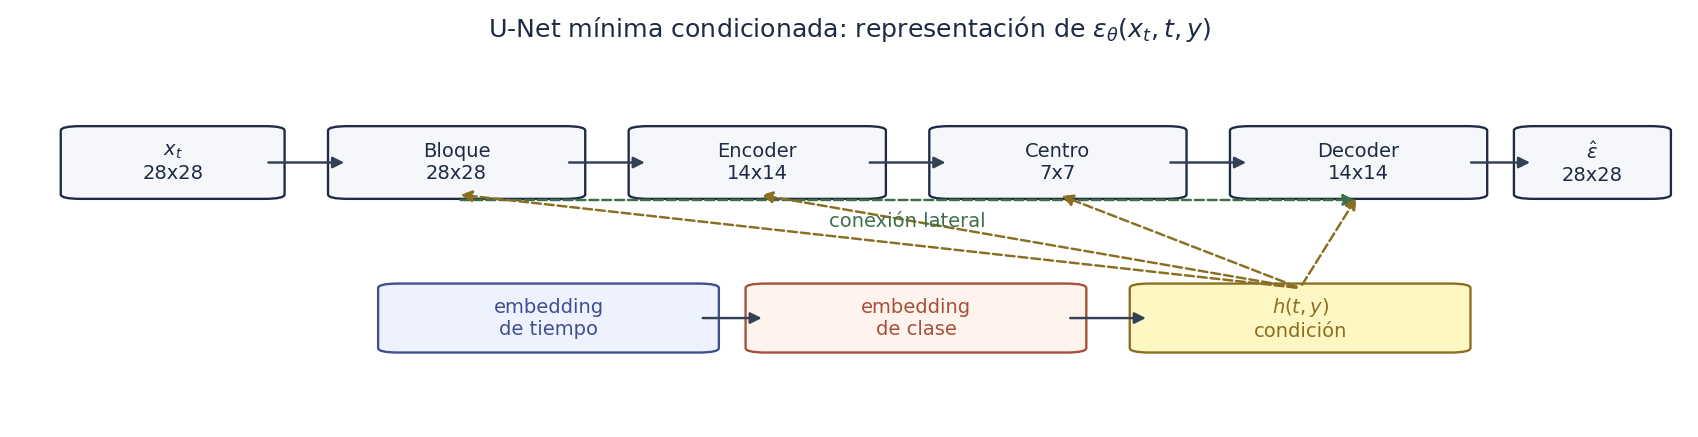

In [6]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch


def add_box(ax, xy, w, h, text, color="#1f2a44", face="#f5f7fa", fontsize=10):
    patch = FancyBboxPatch(
        xy,
        w,
        h,
        boxstyle="round,pad=0.012,rounding_size=0.012",
        facecolor=face,
        edgecolor=color,
        linewidth=1.2,
    )
    ax.add_patch(patch)
    ax.text(xy[0] + w / 2, xy[1] + h / 2, text, ha="center", va="center", fontsize=fontsize, color=color)


def add_arrow(ax, start, end, color="#344054", ls="-"):
    ax.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle="-|>",
            mutation_scale=12,
            linewidth=1.25,
            linestyle=ls,
            color=color,
        )
    )


fig, ax = plt.subplots(figsize=(12, 3.0))
ax.set_axis_off()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

add_box(ax, (0.04, 0.61), 0.11, 0.17, "$x_t$\n28x28")
add_box(ax, (0.20, 0.61), 0.13, 0.17, "Bloque\n28x28")
add_box(ax, (0.38, 0.61), 0.13, 0.17, "Encoder\n14x14")
add_box(ax, (0.56, 0.61), 0.13, 0.17, "Centro\n7x7")
add_box(ax, (0.74, 0.61), 0.13, 0.17, "Decoder\n14x14")
add_box(ax, (0.91, 0.61), 0.07, 0.17, "$\\hat{\\epsilon}$\n28x28")

for start, end in [
    ((0.15, 0.695), (0.20, 0.695)),
    ((0.33, 0.695), (0.38, 0.695)),
    ((0.51, 0.695), (0.56, 0.695)),
    ((0.69, 0.695), (0.74, 0.695)),
    ((0.87, 0.695), (0.91, 0.695)),
]:
    add_arrow(ax, start, end)

add_arrow(ax, (0.265, 0.595), (0.805, 0.595), color="#3f6f4a", ls="--")
ax.text(0.535, 0.54, "conexión lateral", ha="center", va="center", color="#3f6f4a", fontsize=10)

add_box(ax, (0.23, 0.20), 0.18, 0.16, "embedding\nde tiempo", color="#3f4f8f", face="#eef2ff")
add_box(ax, (0.45, 0.20), 0.18, 0.16, "embedding\nde clase", color="#a84f3b", face="#fff4ed")
add_box(ax, (0.68, 0.20), 0.18, 0.16, "$h(t,y)$\ncondición", color="#8a6f22", face="#fef7c3")

add_arrow(ax, (0.41, 0.28), (0.45, 0.28), color="#344054")
add_arrow(ax, (0.63, 0.28), (0.68, 0.28), color="#344054")
for x_target in [0.265, 0.445, 0.625, 0.805]:
    add_arrow(ax, (0.77, 0.36), (x_target, 0.61), color="#8a6f22", ls="--")

ax.set_title(r"U-Net mínima condicionada: representación de $\epsilon_\theta(x_t,t,y)$", fontsize=13, color="#1f2a44")
fig.tight_layout(pad=0.25)

## Entrenamiento y recuperación del modelo

En cada mini-lote se muestrean tiempos $t$ de forma uniforme, se genera $x_t$ con ruido gaussiano y se optimiza la pérdida cuadrática entre el ruido real y el ruido predicho. La etiqueta acompaña a cada imagen durante todo el proceso de entrenamiento.

Para mantener reproducible la ejecución, la celda siguiente carga el checkpoint si ya existe. Si el archivo no está disponible, entrena el modelo desde cero y almacena pesos, configuración e historial de pérdida.

In [7]:
LEARNING_RATE = 2e-4
EPOCHS = 40


def train_model(model, loader):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    loss_history = []
    epoch_history = []
    start_time = time.perf_counter()

    model.train()
    for epoch in range(1, EPOCHS + 1):
        epoch_losses = []
        for x0, labels in loader:
            x0 = x0.to(DEVICE)
            labels = labels.to(DEVICE)
            b = x0.shape[0]
            t_index = torch.randint(0, T, (b,), device=DEVICE)
            eps = torch.randn_like(x0)
            xt, eps = q_sample(x0, t_index, eps)
            eps_pred = model(xt, t_index, labels)
            loss = torch.mean((eps - eps_pred) ** 2)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            value = float(loss.detach().cpu())
            loss_history.append(value)
            epoch_losses.append(value)

        epoch_mean = float(np.mean(epoch_losses))
        epoch_history.append(epoch_mean)
        print(f"época {epoch:02d}/{EPOCHS} | loss promedio={epoch_mean:.4f} | loss final={epoch_losses[-1]:.4f}")

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start_time
    print(f"Tiempo total de entrenamiento: {elapsed:.2f} s")
    return loss_history, epoch_history, elapsed


CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

if CHECKPOINT_PATH.exists():
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    loss_history = checkpoint.get("loss_history", [])
    epoch_history = checkpoint.get("epoch_history", [])
    training_time = checkpoint.get("training_time_seconds", None)
    print("Checkpoint cargado.")
    if epoch_history:
        print(f"Épocas almacenadas: {len(epoch_history)} | última pérdida promedio: {epoch_history[-1]:.4f}")
else:
    loss_history, epoch_history, training_time = train_model(model, loader)
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "loss_history": loss_history,
        "epoch_history": epoch_history,
        "training_time_seconds": training_time,
        "class_names": class_names.tolist(),
        "config": {
            "T": T,
            "beta_inicio": beta_inicio,
            "beta_fin": beta_fin,
            "num_classes": NUM_CLASSES,
            "max_per_class": MAX_PER_CLASS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "epochs": EPOCHS,
            "cond_dim": 96,
            "base": 64,
        },
    }
    torch.save(checkpoint, CHECKPOINT_PATH)
    print("Checkpoint guardado en:", CHECKPOINT_PATH.relative_to(ROOT))

Checkpoint cargado.
Épocas almacenadas: 40 | última pérdida promedio: 0.0572


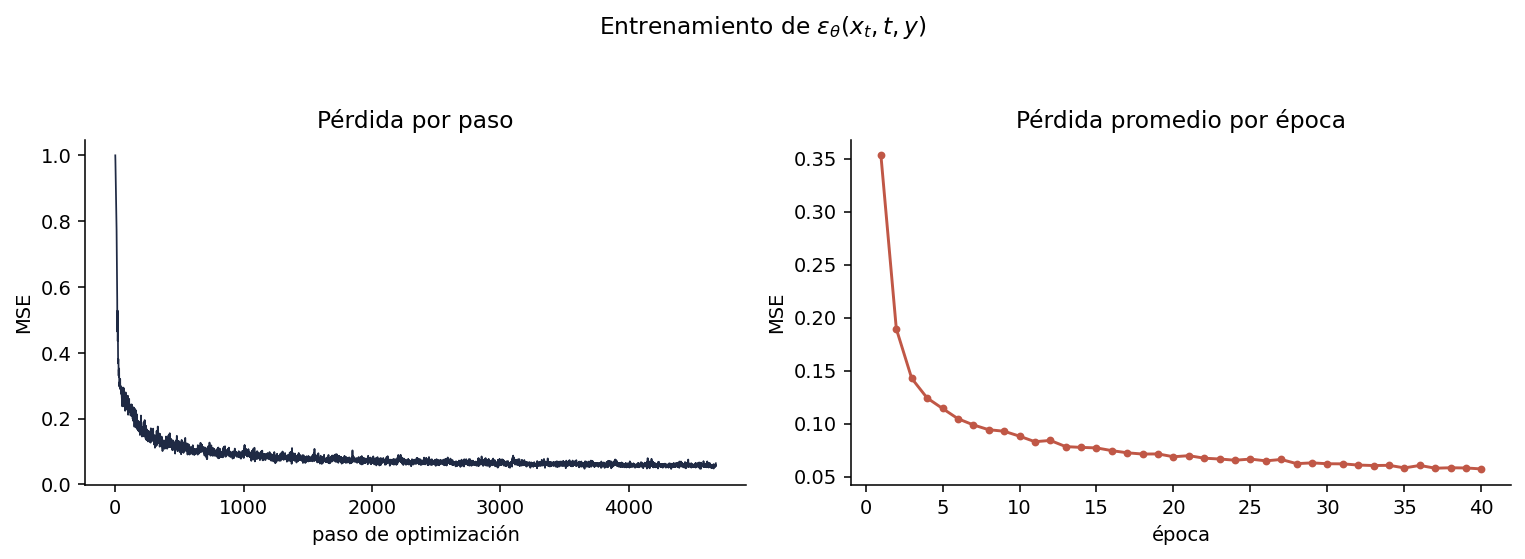

In [8]:
if loss_history:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    axes[0].plot(loss_history, color="#1f2a44", linewidth=0.9)
    axes[0].set_title("Pérdida por paso")
    axes[0].set_xlabel("paso de optimización")
    axes[0].set_ylabel("MSE")
    axes[1].plot(range(1, len(epoch_history) + 1), epoch_history, color="#c05746", marker="o", markersize=3)
    axes[1].set_title("Pérdida promedio por época")
    axes[1].set_xlabel("época")
    axes[1].set_ylabel("MSE")
    fig.suptitle(r"Entrenamiento de $\epsilon_\theta(x_t,t,y)$", y=1.04)
    fig.tight_layout()
else:
    print("No hay historial de pérdida disponible en el checkpoint.")

## Denoising condicionado

Antes de generar desde ruido puro, evaluamos una tarea más directa. Tomamos imágenes reales, las perturbamos en un tiempo intermedio y usamos el modelo para estimar el ruido. Luego reconstruimos una aproximación de $x_0$.

Esta prueba no demuestra generación completa, pero sí verifica que la red aprendió una operación de denoising dependiente de la clase.

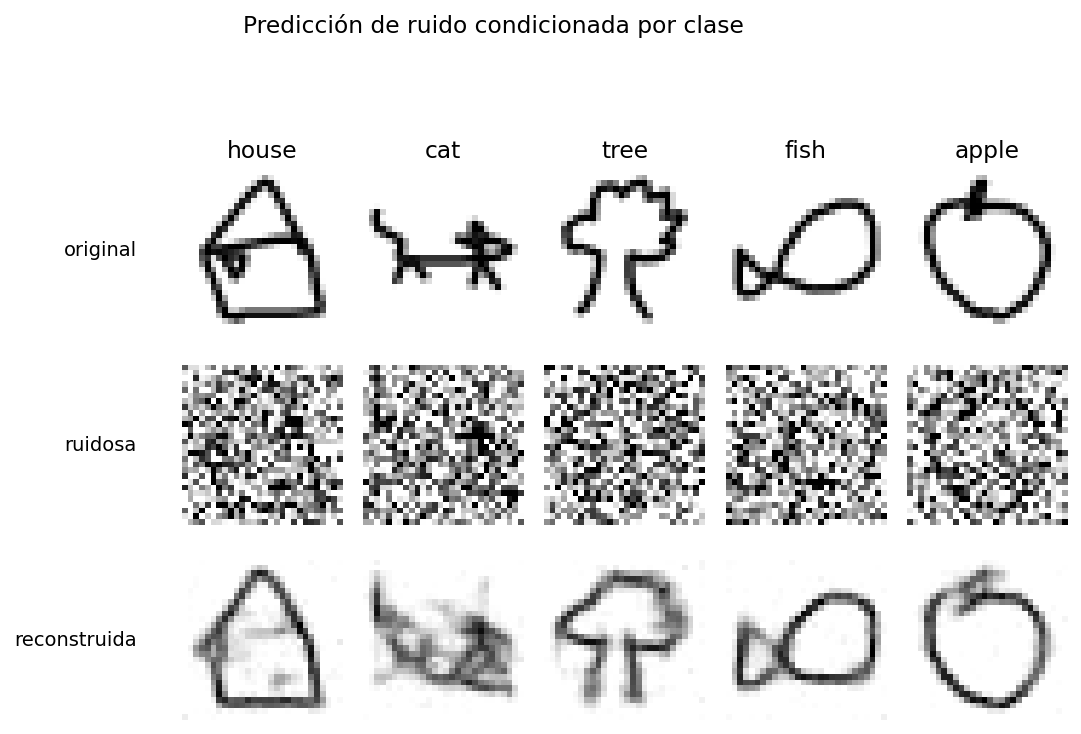

In [9]:
def to_image_range(x):
    return torch.clamp((x + 1.0) / 2.0, 0.0, 1.0)


def reconstruct_x0_from_epsilon(xt, eps_pred, t_index):
    alpha_bar_t = alpha_bars[t_index].view(-1, 1, 1, 1)
    return (xt - torch.sqrt(1.0 - alpha_bar_t) * eps_pred) / torch.sqrt(alpha_bar_t)


model.eval()
chosen_indices = []
for k in range(NUM_CLASSES):
    idx = np.flatnonzero(y_train == k)
    chosen_indices.append(rng.choice(idx))

x0 = x_tensor[chosen_indices].to(DEVICE)
labels = y_tensor[chosen_indices].to(DEVICE)
t_index = torch.full((NUM_CLASSES,), int(0.55 * T), device=DEVICE, dtype=torch.long)
eps = torch.randn_like(x0)
xt, eps = q_sample(x0, t_index, eps)

with torch.no_grad():
    eps_pred = model(xt, t_index, labels)
    x0_hat = reconstruct_x0_from_epsilon(xt, eps_pred, t_index)

fig, axes = plt.subplots(3, NUM_CLASSES, figsize=(NUM_CLASSES * 1.7, 5.1))
rows = [("original", x0), ("ruidosa", xt), ("reconstruida", x0_hat)]
for row, (row_name, tensor) in enumerate(rows):
    for col in range(NUM_CLASSES):
        axes[row, col].imshow(to_image_range(tensor[col, 0]).detach().cpu(), vmin=0, vmax=1)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(str(class_names[col]))
        if col == 0:
            axes[row, col].text(-0.28, 0.5, row_name, transform=axes[row, col].transAxes, ha="right", va="center")
fig.suptitle("Predicción de ruido condicionada por clase", y=1.03)
fig.tight_layout(rect=[0.08, 0.0, 1.0, 0.96])

## Muestreo inverso condicionado

Ahora usamos el modelo como generador. Iniciamos desde ruido gaussiano y recorremos la cadena inversa fijando una etiqueta. La distribución inicial es la misma para todas las clases; la diferencia está en la condición usada por la red en cada paso.

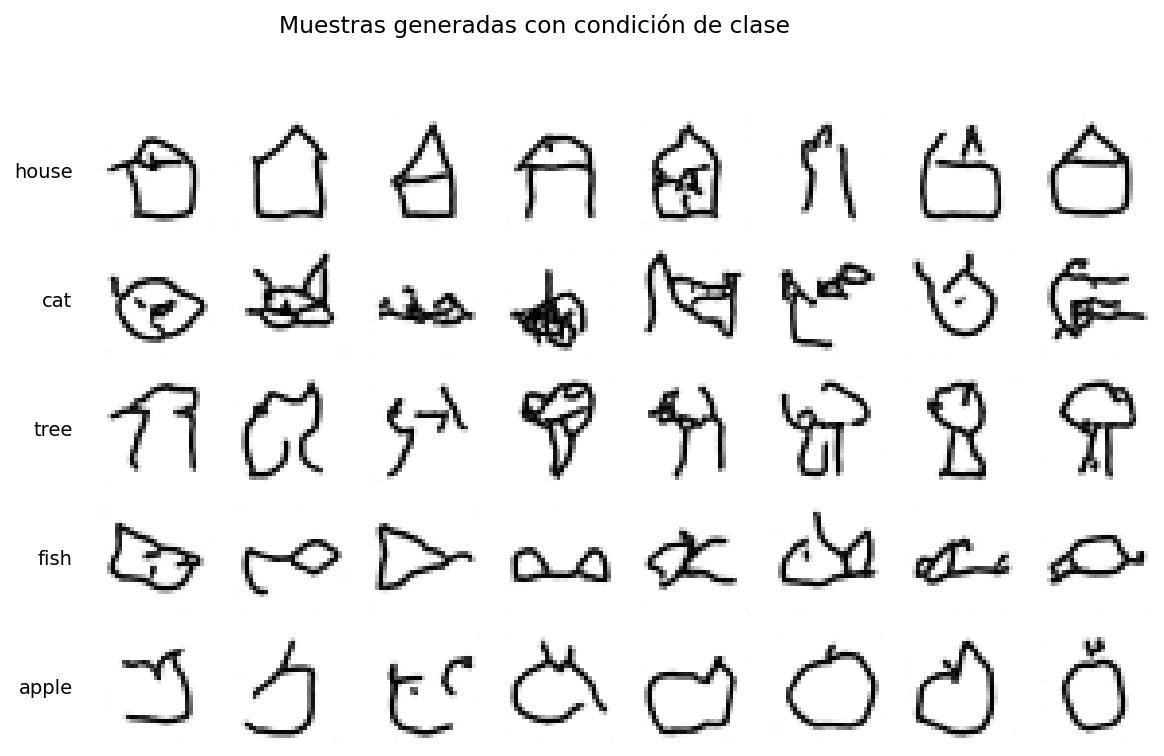

In [10]:
@torch.no_grad()
def sample_ddpm(model, labels, initial_noise=None, save_steps=None):
    model.eval()
    labels = labels.to(DEVICE)
    n = labels.shape[0]
    if initial_noise is None:
        x = torch.randn(n, 1, 28, 28, device=DEVICE)
    else:
        x = initial_noise.to(DEVICE).clone()

    snapshots = {}
    save_steps = set(save_steps or [])

    for t in reversed(range(T)):
        t_batch = torch.full((n,), t, device=DEVICE, dtype=torch.long)
        eps_pred = model(x, t_batch, labels)

        beta_t = betas[t].view(1, 1, 1, 1)
        alpha_t = alphas[t].view(1, 1, 1, 1)
        alpha_bar_t = alpha_bars[t].view(1, 1, 1, 1)
        if t > 0:
            alpha_bar_prev = alpha_bars[t - 1].view(1, 1, 1, 1)
            posterior_var = beta_t * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t)
            z = torch.randn_like(x)
        else:
            posterior_var = torch.zeros_like(beta_t)
            z = torch.zeros_like(x)

        mean = (1.0 / torch.sqrt(alpha_t)) * (
            x - beta_t / torch.sqrt(1.0 - alpha_bar_t) * eps_pred
        )
        x = mean + torch.sqrt(posterior_var) * z

        if t in save_steps:
            snapshots[t] = x.detach().cpu()

    snapshots[0] = x.detach().cpu()
    return x.detach().cpu(), snapshots


samples_per_class = 8
labels = torch.arange(NUM_CLASSES).repeat_interleave(samples_per_class)
final_samples, snapshots = sample_ddpm(model, labels, save_steps=[T - 1, 375, 250, 125, 0])

fig, axes = plt.subplots(NUM_CLASSES, samples_per_class, figsize=(samples_per_class * 1.15, NUM_CLASSES * 1.05))
for k, name in enumerate(class_names):
    for j in range(samples_per_class):
        idx = k * samples_per_class + j
        axes[k, j].imshow(to_image_range(final_samples[idx, 0]), vmin=0, vmax=1)
        axes[k, j].axis("off")
        if j == 0:
            axes[k, j].text(-0.28, 0.5, str(name), transform=axes[k, j].transAxes, ha="right", va="center", fontsize=10)
fig.suptitle("Muestras generadas con condición de clase", y=1.02)
fig.tight_layout(rect=[0.08, 0.0, 1.0, 0.97])

## Trayectoria inversa por clase

La siguiente visualización guarda estados intermedios de la cadena inversa para una muestra por clase. No debe interpretarse como una interpolación lineal. Es una trayectoria estocástica guiada por la predicción de ruido de la red condicionada.

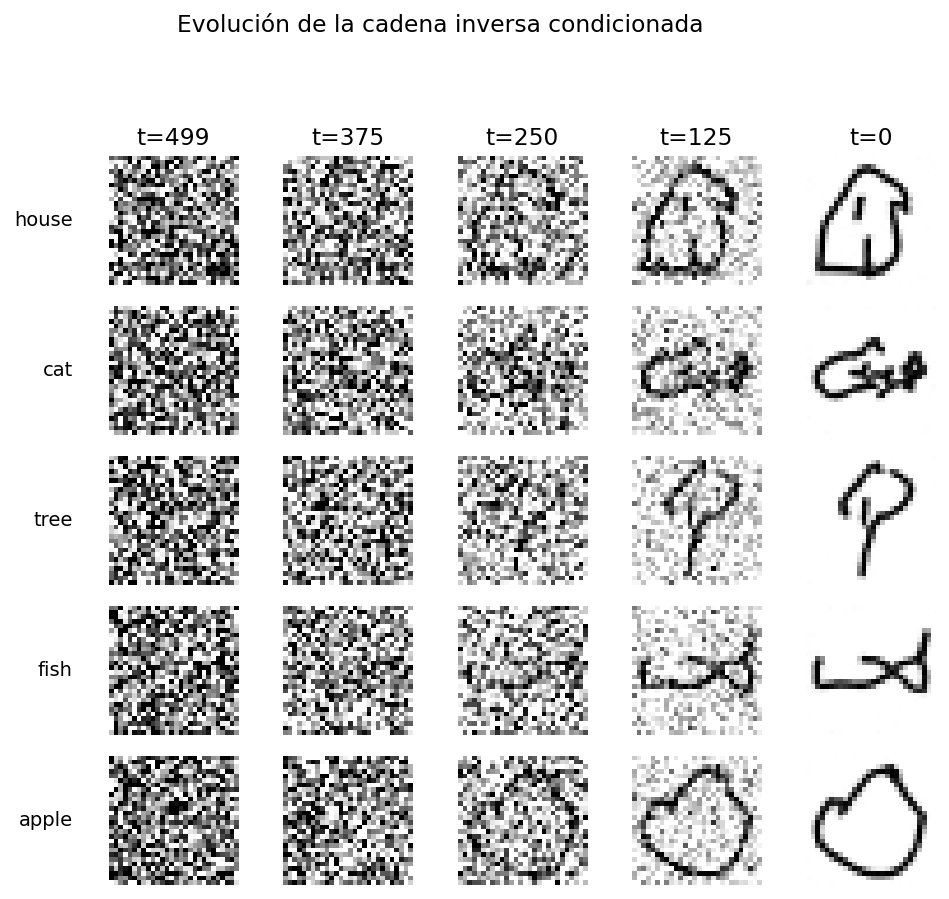

In [11]:
step_order = [T - 1, 375, 250, 125, 0]
trajectory_labels = torch.arange(NUM_CLASSES)
trajectory_samples, trajectory_snapshots = sample_ddpm(
    model,
    trajectory_labels,
    save_steps=step_order,
)

fig, axes = plt.subplots(NUM_CLASSES, len(step_order), figsize=(len(step_order) * 1.55, NUM_CLASSES * 1.25))
for row, name in enumerate(class_names):
    for col, step in enumerate(step_order):
        axes[row, col].imshow(to_image_range(trajectory_snapshots[step][row, 0]), vmin=0, vmax=1)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(f"t={step}")
        if col == 0:
            axes[row, col].text(-0.28, 0.5, str(name), transform=axes[row, col].transAxes, ha="right", va="center", fontsize=10)
fig.suptitle("Evolución de la cadena inversa condicionada", y=1.02)
fig.tight_layout(rect=[0.08, 0.0, 1.0, 0.97])

## Misma semilla, distinta condición

Una prueba más exigente consiste en fijar el mismo ruido inicial para todas las clases y cambiar solamente la etiqueta. Si el modelo usa la condición, la trayectoria inversa debería desplazarse hacia estructuras diferentes.

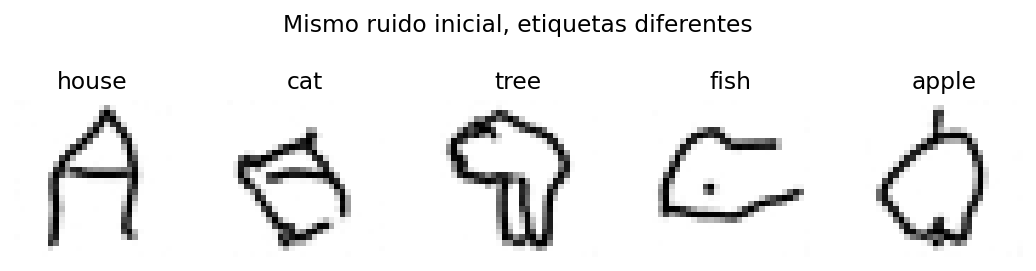

In [12]:
generator = torch.Generator(device=DEVICE).manual_seed(SEED + 77)
shared_noise = torch.randn(1, 1, 28, 28, device=DEVICE, generator=generator).repeat(NUM_CLASSES, 1, 1, 1)
labels = torch.arange(NUM_CLASSES, device=DEVICE)

same_seed_samples, _ = sample_ddpm(model, labels, initial_noise=shared_noise, save_steps=[0])

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(NUM_CLASSES * 1.55, 1.8))
for k, name in enumerate(class_names):
    axes[k].imshow(to_image_range(same_seed_samples[k, 0]), vmin=0, vmax=1)
    axes[k].set_title(str(name))
    axes[k].axis("off")
fig.suptitle("Mismo ruido inicial, etiquetas diferentes", y=1.05)
fig.tight_layout()

## Lectura crítica

El condicionamiento por etiqueta resuelve una limitación del modelo no condicional: permite seleccionar la componente semántica deseada. Sin embargo, la condición discreta no garantiza por sí sola alta fidelidad ni diversidad perfecta. La calidad sigue dependiendo de la arquitectura, la duración del entrenamiento, la agenda de ruido y el procedimiento de muestreo.

En este experimento, el modelo es intencionalmente pequeño. Si una muestra aparece incompleta o ambigua, eso no invalida la formulación condicional; indica que la aproximación aprendida todavía tiene capacidad limitada. Lo importante es observar que $y$ cambia la distribución de salida sin cambiar el ruido inicial ni el proceso directo.

## Síntesis

Un DDPM condicional mantiene el mismo proceso directo gaussiano, pero modifica la red de denoising para que dependa de una condición. En el caso discreto, esa condición se representa mediante un embedding de clase y se combina con el embedding temporal. El objetivo pasa de predecir ruido para la mezcla completa a predecir ruido dentro de una componente seleccionada:

$$
\epsilon_\theta(x_t,t)
\quad\longrightarrow\quad
\epsilon_\theta(x_t,t,y).
$$

La implementación mostró el ciclo completo: dataset etiquetado, mini-lotes condicionados, U-Net pequeña con embeddings de clase, entrenamiento por MSE y muestreo inverso fijando una etiqueta. Este es el primer punto del curso en el que el estudiante puede solicitar explícitamente una clase durante la generación.

## Preguntas de discusión

1. ¿Por qué no es necesario modificar $q(x_t\mid x_0)$ al introducir etiquetas?
2. ¿Qué representa exactamente la tabla de embeddings $E\in\mathbb{R}^{K\times m}$?
3. ¿Qué diferencia estadística hay entre entrenar $\epsilon_\theta(x_t,t)$ sobre una mezcla y entrenar $\epsilon_\theta(x_t,t,y)$?
4. ¿Por qué usar el mismo ruido inicial con distintas etiquetas ayuda a evaluar si el modelo usa la condición?
5. ¿Qué limitaciones aparecen cuando solo usamos etiquetas discretas y no incorporamos mecanismos de guidance?

## Continuidad

El siguiente paso será estudiar classifier-free guidance. Allí entrenaremos un modelo capaz de operar con condición presente y condición ausente. Esa doble capacidad permitirá controlar la fuerza de la condición durante el muestreo, pasando de generación condicional simple a generación guiada.